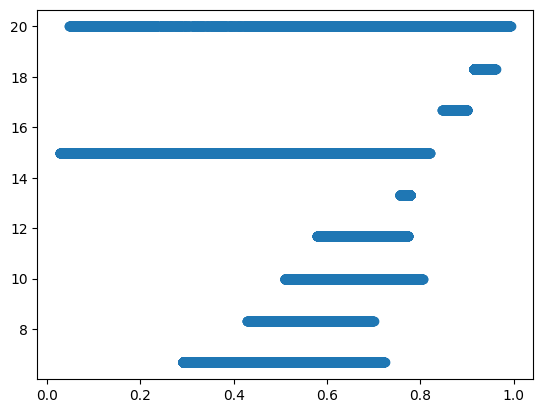

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"Removed_Outliers.csv")

plt.scatter(df['TGS2620-3'], df['Ethylene con: (ppm)'])
plt.show()

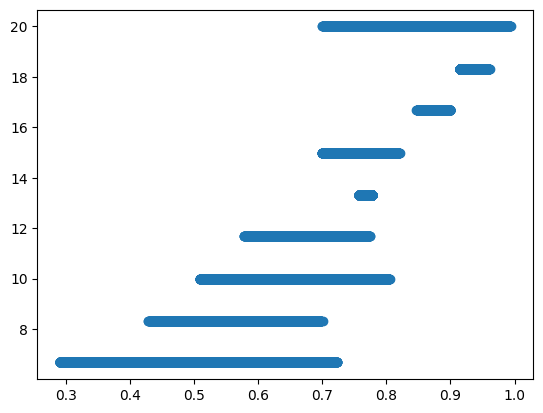

In [4]:
condition = (df['Ethylene con: (ppm)'] > 14) & (df['TGS2620-3'] < 0.7)
df_drop1 = df[~condition]
plt.scatter(df_drop1['TGS2620-3'], df_drop1['Ethylene con: (ppm)'])
plt.show()

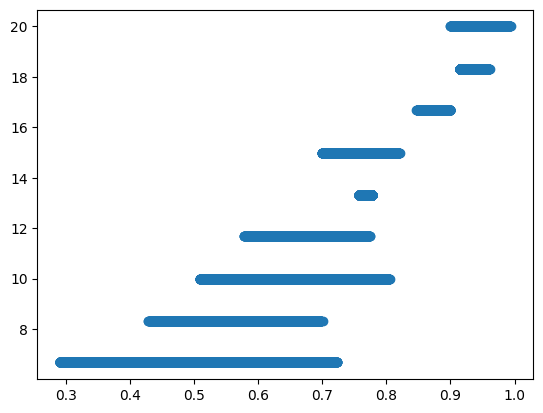

In [5]:
condition = (df_drop1['Ethylene con: (ppm)'] > 19) & (df_drop1['TGS2620-3'] < 0.9)
df_drop2 = df_drop1[~condition]
plt.scatter(df_drop2['TGS2620-3'], df_drop2['Ethylene con: (ppm)'])
plt.show()

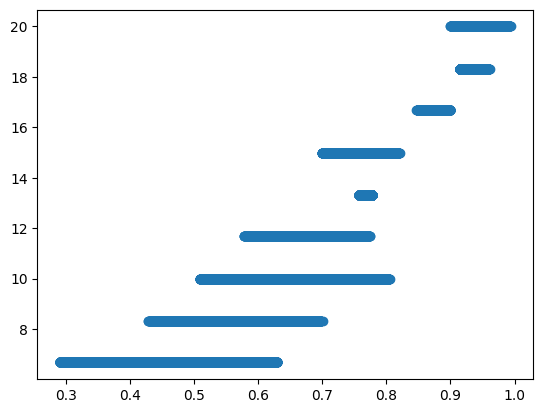

In [7]:
condition = (df_drop2['Ethylene con: (ppm)'] < 8) & (df_drop2['TGS2620-3'] > 0.63)
df_drop3 = df_drop2[~condition]
plt.scatter(df_drop3['TGS2620-3'], df_drop3['Ethylene con: (ppm)'])
plt.show()

In [8]:
df_drop3= df_drop3.iloc[:, 3:]
new_name = {'Ethylene con: (ppm).1': 'Ethylene con: (ppm)'}
df_drop3= df_drop3.rename(columns=new_name)
df_drop3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1240302 entries, 0 to 1265338
Data columns (total 19 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   Time(sec)            1240302 non-null  float64
 1   Methane con: (ppm)   1240302 non-null  float64
 2   Ethylene con: (ppm)  1240302 non-null  float64
 3   TGS2602-1            1240302 non-null  float64
 4   TGS2602-2            1240302 non-null  float64
 5   TGS2600-1            1240302 non-null  float64
 6   TGS2600-2            1240302 non-null  float64
 7   TGS2610-1            1240302 non-null  float64
 8   TGS2610-2            1240302 non-null  float64
 9   TGS2620-1            1240302 non-null  float64
 10  TGS2620-2            1240302 non-null  float64
 11  TGS2602-3            1240302 non-null  float64
 12  TGS2602-4            1240302 non-null  float64
 13  TGS2600-3            1240302 non-null  float64
 14  TGS2600-4            1240302 non-null  float64
 15  TGS

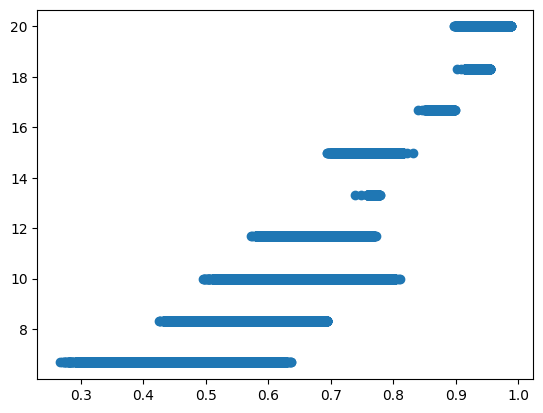

In [12]:
#Savitzky-Golay Filtering

from scipy.signal import savgol_filter

data_frame = df_drop3.copy()

columns_to_filter = [
 'TGS2602-1',
 'TGS2602-2',
 'TGS2600-1',
 'TGS2600-2',
 'TGS2610-1',
 'TGS2610-2',
 'TGS2620-1',
 'TGS2620-2',
 'TGS2602-3',
 'TGS2602-4',
 'TGS2600-3',
 'TGS2600-4',
 'TGS2610-3',
 'TGS2610-4',
 'TGS2620-3',
 'TGS2620-4']

# Savitzky-Golay filter 
def apply_savgol(series, window_length, polyorder):
    return savgol_filter(series, window_length, polyorder)

window_length = 15
polyorder = 3

# Apply filter to selected columns
for col in columns_to_filter:
  data_frame[col] = apply_savgol(data_frame[col], window_length, polyorder)

plt.scatter(data_frame['TGS2620-3'], data_frame['Ethylene con: (ppm)'])
plt.show()

In [13]:
#log normalisation
import numpy as np

data_frame['Ethylene con: (ppm)'] = np.log(data_frame['Ethylene con: (ppm)'])

data_frame.to_csv(r"Final_Data.csv")

In [14]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1240302 entries, 0 to 1265338
Data columns (total 19 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   Time(sec)            1240302 non-null  float64
 1   Methane con: (ppm)   1240302 non-null  float64
 2   Ethylene con: (ppm)  1240302 non-null  float64
 3   TGS2602-1            1240302 non-null  float64
 4   TGS2602-2            1240302 non-null  float64
 5   TGS2600-1            1240302 non-null  float64
 6   TGS2600-2            1240302 non-null  float64
 7   TGS2610-1            1240302 non-null  float64
 8   TGS2610-2            1240302 non-null  float64
 9   TGS2620-1            1240302 non-null  float64
 10  TGS2620-2            1240302 non-null  float64
 11  TGS2602-3            1240302 non-null  float64
 12  TGS2602-4            1240302 non-null  float64
 13  TGS2600-3            1240302 non-null  float64
 14  TGS2600-4            1240302 non-null  float64
 15  TGS